# 01 — Olink-style NPX QC and ML-ready data preparation

This notebook demonstrates the first capability layer of a clinical proteomics AI pipeline:

1. load or generate Olink-style long-format NPX data
2. inspect expected NPX schema and clinical metadata
3. run sample-level and protein-level QC
4. assess missingness and below-LOD behaviour
5. convert long-format proteomics data into a wide ML-ready matrix
6. save clean `X`, `y`, and metadata files for downstream modelling

The included dataset is synthetic and safe for public GitHub use. It is designed to mimic key Olink-style fields, not to reproduce a real Olink study.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from proteomics_index.synthetic_data import SyntheticOlinkConfig, generate_synthetic_olink_npx
from proteomics_index.qc import summarize_npx, sample_qc_table, protein_qc_table, filter_npx, long_to_wide

DATA_SAMPLE = ROOT / "data" / "sample"
DATA_PROCESSED = ROOT / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

## 1. Load synthetic Olink-style NPX data

In a real project, this would usually come from exported Olink NPX software files. Here, we use a small synthetic dataset with the same kind of long-format structure.

In [2]:
npx_path = DATA_SAMPLE / "olink_synthetic_npx.csv"
meta_path = DATA_SAMPLE / "sample_metadata.csv"

if not npx_path.exists() or not meta_path.exists():
    npx, metadata = generate_synthetic_olink_npx(
        SyntheticOlinkConfig(n_samples=96, n_proteins=240, signal_proteins=20, random_state=42)
    )
    npx.to_csv(npx_path, index=False)
    metadata.to_csv(meta_path, index=False)
else:
    npx = pd.read_csv(npx_path)
    metadata = pd.read_csv(meta_path)

print("NPX long shape:", npx.shape)
print("Metadata shape:", metadata.shape)
display(npx.head())
display(metadata.head())

NPX long shape: (23040, 12)
Metadata shape: (96, 11)


,SampleID,OlinkID,UniProt,Assay,Panel,NPX,LOD,QC_Warning,PlateID,SampleQC,BelowLOD,MissingFreq
0,S001,OID10000,P10000,Protein_000,Olink Inflammation,8.2924,7.2227,Pass,Plate_C,Pass,False,0.031250
1,S001,OID10001,P10001,Protein_001,Olink Cardiometabolic,7.1298,6.0339,Pass,Plate_C,Pass,False,0.010417
2,S001,OID10002,P10002,Protein_002,Olink Neurology,9.2307,8.5569,Pass,Plate_C,Pass,False,0.010417
3,S001,OID10003,P10003,Protein_003,Olink Oncology,8.4142,6.9708,Pass,Plate_C,Pass,False,0.000000
4,S001,OID10004,P10004,Protein_004,Olink Inflammation,6.8576,4.7018,Pass,Plate_C,Pass,False,0.000000


,SampleID,SubjectID,Age,Sex,BMI,DiseaseStatus,WHO_Severity,SevereOutcome,CollectionDay,PlateID,SampleQC
0,S001,P001,29,Male,17.0,Control,1,0,22,Plate_C,Pass
1,S002,P002,68,Female,28.3,Case,4,0,20,Plate_C,Pass
2,S003,P003,61,Female,22.9,Control,3,0,1,Plate_C,Warning
3,S004,P004,49,Female,24.9,Control,4,0,5,Plate_C,Pass
4,S005,P005,49,Male,23.9,Control,3,0,0,Plate_C,Pass


## 2. Expected Olink-style fields

Typical downstream workflows need enough metadata to distinguish sample-level QC, assay-level QC, protein identity, panels, limit-of-detection behaviour, and expression values.

In [3]:
expected_columns = [
    "SampleID", "OlinkID", "UniProt", "Assay", "Panel", "NPX", "LOD",
    "QC_Warning", "PlateID", "SampleQC", "BelowLOD", "MissingFreq"
]

schema_check = pd.DataFrame({
    "column": expected_columns,
    "present": [c in npx.columns for c in expected_columns],
    "dtype": [str(npx[c].dtype) if c in npx.columns else "missing" for c in expected_columns],
})
display(schema_check)

,column,present,dtype
0,SampleID,True,object
1,OlinkID,True,object
2,UniProt,True,object
3,Assay,True,object
4,Panel,True,object
5,NPX,True,float64
6,LOD,True,float64
7,QC_Warning,True,object
8,PlateID,True,object
9,SampleQC,True,object


## 3. Global QC summary

This gives a fast read on whether the dataset is usable for modelling or needs more intensive data cleaning.

In [4]:
summary = summarize_npx(npx)
display(summary)

,value
rows,23040.000000
samples,96.000000
proteins,240.000000
panels,4.000000
missing_npx_rate,0.013628
below_lod_rate,0.024696
sample_qc_warning_rate,0.114583
assay_qc_warning_rate,0.035981


## 4. Sample-level QC

Samples with high missingness or repeated assay warnings can distort index scoring and model validation. In regulated clinical AI, the filtering threshold should be documented and justified.

,SampleID,n_proteins,missing_rate,below_lod_rate,sample_qc,assay_warning_rate
71,S072,240,0.037500,0.054167,Pass,0.041667
2,S003,240,0.029167,0.033333,Warning,0.008333
24,S025,240,0.029167,0.037500,Pass,0.033333
20,S021,240,0.029167,0.033333,Pass,0.045833
58,S059,240,0.029167,0.033333,Pass,0.062500
65,S066,240,0.029167,0.033333,Pass,0.033333
62,S063,240,0.025000,0.041667,Pass,0.020833
74,S075,240,0.025000,0.025000,Warning,0.037500
56,S057,240,0.025000,0.033333,Pass,0.029167
54,S055,240,0.025000,0.037500,Pass,0.020833


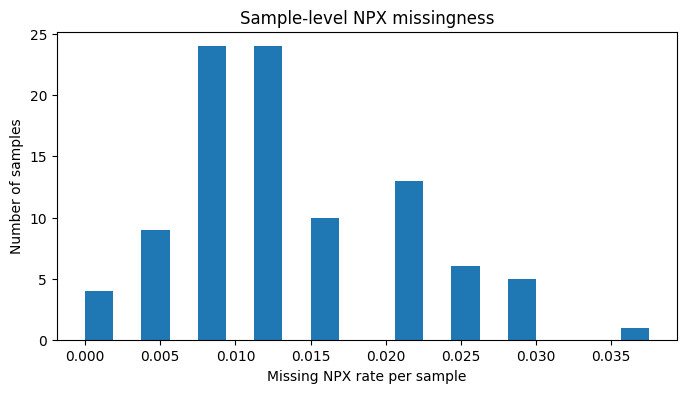

In [5]:
sample_qc = sample_qc_table(npx)
display(sample_qc.head(10))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sample_qc["missing_rate"], bins=20)
ax.set_title("Sample-level NPX missingness")
ax.set_xlabel("Missing NPX rate per sample")
ax.set_ylabel("Number of samples")
plt.show()

## 5. Protein-level QC

Protein-level QC helps identify assays with poor detectability or high missingness. This is especially important in high-dimensional small-sample ML, where noisy proteins can dominate spurious model performance.

,OlinkID,UniProt,Assay,Panel,missing_rate,below_lod_rate,mean_npx,sd_npx,assay_warning_rate
75,OID10075,P10075,Protein_075,Olink Oncology,0.062500,0.062500,8.541012,0.857420,0.072917
97,OID10097,P10097,Protein_097,Olink Cardiometabolic,0.052083,0.072917,8.425669,0.814875,0.020833
32,OID10032,P10032,Protein_032,Olink Inflammation,0.041667,0.072917,8.309250,0.956333,0.052083
47,OID10047,P10047,Protein_047,Olink Oncology,0.041667,0.052083,8.360252,0.957581,0.020833
18,OID10018,P10018,Protein_018,Olink Neurology,0.041667,0.083333,8.238036,0.886792,0.052083
101,OID10101,P10101,Protein_101,Olink Cardiometabolic,0.041667,0.041667,8.527689,0.865466,0.020833
150,OID10150,P10150,Protein_150,Olink Neurology,0.041667,0.052083,8.500735,0.959922,0.020833
155,OID10155,P10155,Protein_155,Olink Oncology,0.041667,0.052083,8.513301,0.838765,0.072917
178,OID10178,P10178,Protein_178,Olink Neurology,0.041667,0.052083,8.547010,0.897607,0.031250
188,OID10188,P10188,Protein_188,Olink Inflammation,0.041667,0.052083,8.626330,1.067898,0.031250


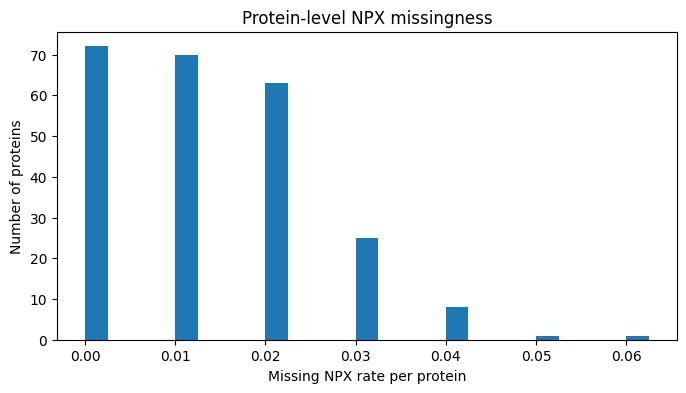

In [6]:
protein_qc = protein_qc_table(npx)
display(protein_qc.head(10))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(protein_qc["missing_rate"], bins=25)
ax.set_title("Protein-level NPX missingness")
ax.set_xlabel("Missing NPX rate per protein")
ax.set_ylabel("Number of proteins")
plt.show()

## 6. NPX distribution by panel

Panel-level distribution checks can reveal batch effects, panel-specific shifts, or poor normalization.

/tmp/ipykernel_3102/2537345904.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=sorted(npx["Panel"].unique()), vert=True)


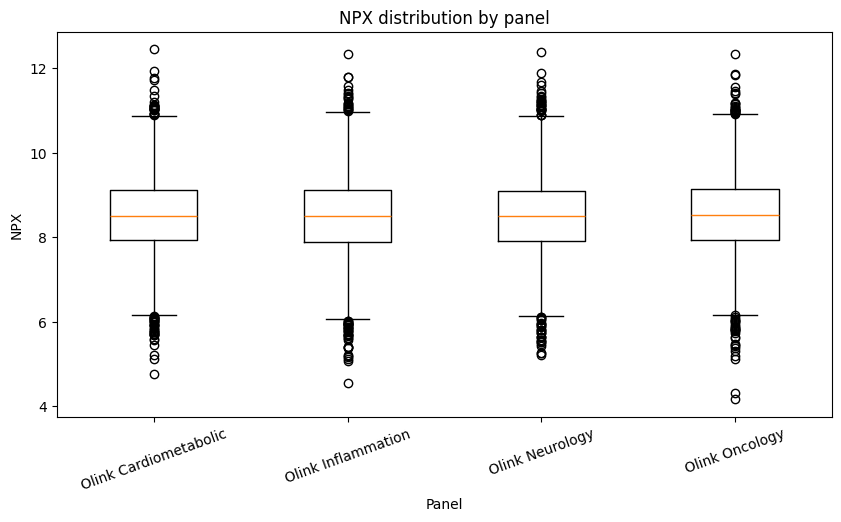

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_data = [npx.loc[npx["Panel"] == panel, "NPX"].dropna() for panel in sorted(npx["Panel"].unique())]
ax.boxplot(plot_data, labels=sorted(npx["Panel"].unique()), vert=True)
ax.set_title("NPX distribution by panel")
ax.set_xlabel("Panel")
ax.set_ylabel("NPX")
ax.tick_params(axis="x", rotation=20)
plt.show()

## 7. Filter and pivot to ML-ready matrix

The central transformation for most ML workflows is long-format NPX → wide sample-by-protein matrix.

Important: the same filtering rules must be applied inside a documented pipeline when developing clinical-grade systems.

In [8]:
filtered_npx = filter_npx(
    npx,
    max_sample_missing=0.35,
    max_protein_missing=0.40,
    keep_sample_qc_warning=True,
)

X_wide = long_to_wide(filtered_npx, feature_col="Assay")
model_table = metadata.merge(X_wide, on="SampleID", how="inner")

protein_features = [c for c in X_wide.columns if c != "SampleID"]
X = model_table[protein_features]
y = model_table["SevereOutcome"].astype(int)
metadata_model = model_table[[
    "SampleID", "SubjectID", "Age", "Sex", "BMI", "DiseaseStatus",
    "WHO_Severity", "SevereOutcome", "CollectionDay", "PlateID", "SampleQC"
]]

print("Filtered long NPX shape:", filtered_npx.shape)
print("ML matrix shape:", X.shape)
print("Number of samples:", X.shape[0])
print("Number of protein features:", X.shape[1])
print("p > n:", X.shape[1] > X.shape[0])
display(metadata_model.head())

Filtered long NPX shape: (23040, 12)
ML matrix shape: (96, 240)
Number of samples: 96
Number of protein features: 240
p > n: True


,SampleID,SubjectID,Age,Sex,BMI,DiseaseStatus,WHO_Severity,SevereOutcome,CollectionDay,PlateID,SampleQC
0,S001,P001,29,Male,17.0,Control,1,0,22,Plate_C,Pass
1,S002,P002,68,Female,28.3,Case,4,0,20,Plate_C,Pass
2,S003,P003,61,Female,22.9,Control,3,0,1,Plate_C,Warning
3,S004,P004,49,Female,24.9,Control,4,0,5,Plate_C,Pass
4,S005,P005,49,Male,23.9,Control,3,0,0,Plate_C,Pass


## 8. Save processed files for Notebook 02

In [9]:
X_out = DATA_PROCESSED / "X_proteomics.csv"
y_out = DATA_PROCESSED / "y_severe_outcome.csv"
meta_out = DATA_PROCESSED / "metadata_model.csv"

X.assign(SampleID=metadata_model["SampleID"].values).to_csv(X_out, index=False)
y.to_frame("SevereOutcome").assign(SampleID=metadata_model["SampleID"].values).to_csv(y_out, index=False)
metadata_model.to_csv(meta_out, index=False)

print("Saved:")
print("-", X_out.relative_to(ROOT))
print("-", y_out.relative_to(ROOT))
print("-", meta_out.relative_to(ROOT))

Saved:
- data/processed/X_proteomics.csv
- data/processed/y_severe_outcome.csv
- data/processed/metadata_model.csv


## Takeaway

This notebook establishes the **proteomics data-readiness layer**: Olink-style schema handling, QC, missingness review, below-LOD awareness, and long-to-wide conversion. This is the minimum credible foundation before building clinical index scores, confidence logic, or clinician-facing reports.